In [1]:
import numpy as np
import matplotlib.pyplot as plt

from visualization_toolkit.plots.signal import signal_sigma_plot

### Utils

In [2]:
def generate_signal(
    n_measurements: int = 30,
    n_samples: int = 200,
    fs: float = 1.0,
    noise_ratio: float = 5.0,
) -> np.ndarray:
    """
    Generate a synthetic multi-measurement signal array of shape (n_measurements, n_samples).

    Each row is a clean sinusoidal signal with added Gaussian noise.

    Parameters:
        n_measurements: Number of independent measurements (i).
        n_samples: Length of each signal (n).
        fs: Sampling frequency.
        noise_ratio: Ratio sigma_signal / sigma_noise (higher = less noise).

    Returns:
        np.ndarray of shape (n_measurements, n_samples).
    """
    t = np.arange(n_samples) / fs
    clean = np.sin(2 * np.pi * 0.05 * t) + 0.5 * np.sin(2 * np.pi * 0.12 * t)
    sigma_noise = np.std(clean) / noise_ratio
    noise = np.random.normal(0, sigma_noise, size=(n_measurements, n_samples))
    return clean[np.newaxis, :] + noise

### Basic example

data.shape = (50, 200)  # (i, n)


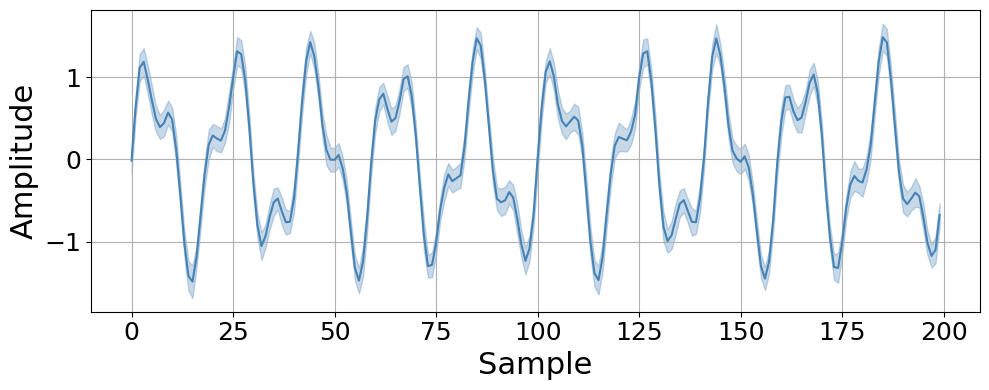

In [3]:
data = generate_signal(n_measurements=50, n_samples=200, noise_ratio=5.0)
print(f"data.shape = {data.shape}  # (i, n)")

signal_sigma_plot(data)
plt.tight_layout()
plt.show()

### Custom sigma and time axis

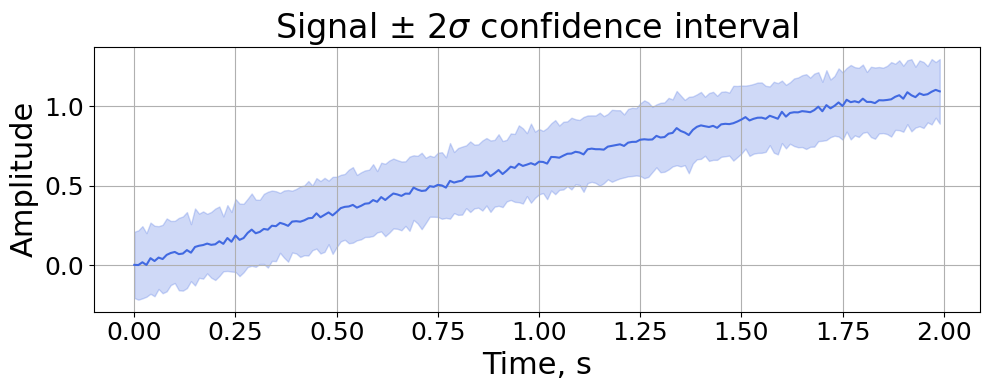

In [4]:
n_samples = 200
fs = 100.0  # Hz
t = np.arange(n_samples) / fs  # time in seconds

data = generate_signal(n_measurements=100, n_samples=n_samples, fs=fs, noise_ratio=3.0)

signal_sigma_plot(
    data,
    sigma=2.0,
    x=t,
    x_label="Time, s",
    y_label="Amplitude",
    title=r"Signal ± 2$\sigma$ confidence interval",
    mean_color="royalblue",
    fill_alpha=0.25,
)
plt.tight_layout()
plt.show()

### Multiple signals on one axes

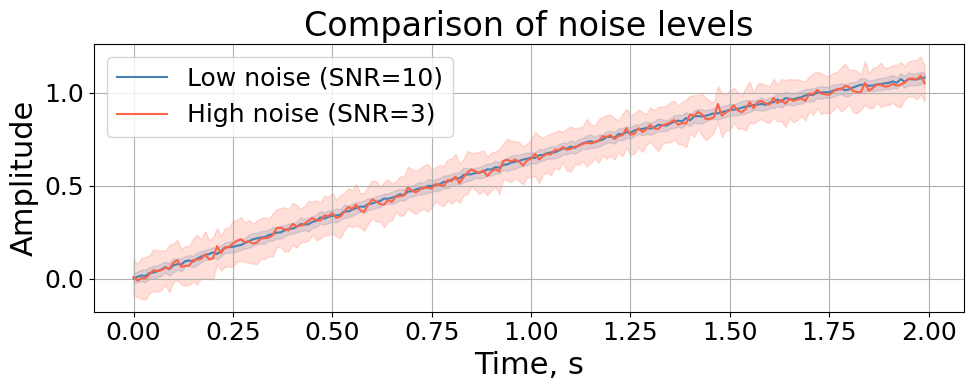

In [5]:
n_samples = 200
fs = 100.0
t = np.arange(n_samples) / fs

configs = [
    {"noise_ratio": 10.0, "color": "steelblue",  "label": "Low noise (SNR=10)"},
    {"noise_ratio": 3.0,  "color": "tomato",     "label": "High noise (SNR=3)"},
]

_, ax = plt.subplots(figsize=(10, 4))

for cfg in configs:
    data = generate_signal(n_measurements=50, n_samples=n_samples, fs=fs, noise_ratio=cfg["noise_ratio"])
    signal_sigma_plot(
        data,
        sigma=1.0,
        x=t,
        x_label="Time, s",
        y_label="Amplitude",
        title="",
        mean_color=cfg["color"],
        fill_alpha=0.2,
        ax=ax,
        label=cfg["label"],
    )

ax.set_title("Comparison of noise levels", fontsize=24)
ax.legend(fontsize=18)
plt.tight_layout()
plt.show()